# RQ1 - Clones (non-agentic vs agentic)

## Preparing data

In [ ]:
#!pip install ijson

### Creating/loading parquet file for faster access

In [2]:
from pathlib import Path
import pandas as pd
import ijson

RESULTS_DIR = Path("../../results")
PARQUET_FILE = RESULTS_DIR/"results.parquet"

if PARQUET_FILE.exists():
    print(f"Loading existing {PARQUET_FILE.name}...")
    df = pd.read_parquet(PARQUET_FILE)

else:
    print("Creating Parquet file...")

    chunks = []

    for file in RESULTS_DIR.glob("*_detailed_results.json"):

        print(f"Processing {file.name}")

        prefix = int(file.name.split("_")[0])

        project = "_".join(file.stem.split("_")[1:-2])

        rows = []

        with open(file, "rb") as f:
            for item in ijson.items(f, "item"):

                rows.append({
                    "file": file.name,
                    "file_index": prefix,
                    "agentic": prefix % 2 == 1,
                    "base_index": prefix - 1 if prefix % 2 else prefix,
                    "project": project,
                    "model": item["model"],
                    "language": item["language"],
                    "sim": item["sim"],
                    "codebleu": item["codebleu"],
                })

        chunks.append(pd.DataFrame(rows))

    df = pd.concat(chunks, ignore_index=True)

    df.to_parquet(PARQUET_FILE, index=False)

    print(f"Saved to {PARQUET_FILE}")

print(df.shape)
df.head()

Loading existing results.parquet...
(30453690, 9)


,file,file_index,agentic,base_index,project,model,language,sim,codebleu
0,0000_codespecs_daikon_05f3ce2b80a0_detailed_re...,0,False,0,codespecs_daikon_05f3ce2b80a0,microsoft/codebert-base-ft,java,1.000000000000000000000000,1.000000000000000000000
1,0000_codespecs_daikon_05f3ce2b80a0_detailed_re...,0,False,0,codespecs_daikon_05f3ce2b80a0,microsoft/codebert-base-ft,java,1.000000000000000000000000,1.000000000000000000000
2,0000_codespecs_daikon_05f3ce2b80a0_detailed_re...,0,False,0,codespecs_daikon_05f3ce2b80a0,microsoft/codebert-base-ft,java,0.090068332850933070000000,0.271311022067892400000
3,0000_codespecs_daikon_05f3ce2b80a0_detailed_re...,0,False,0,codespecs_daikon_05f3ce2b80a0,microsoft/codebert-base-ft,java,0.090068332850933070000000,0.271311022067892400000
4,0000_codespecs_daikon_05f3ce2b80a0_detailed_re...,0,False,0,codespecs_daikon_05f3ce2b80a0,microsoft/codebert-base-ft,java,0.083404108881950380000000,0.258806707184291440000


## Compare distributions

In [3]:
df.groupby("agentic")[["sim", "codebleu"]].mean()

,sim,codebleu
agentic,,
False,0.575282,0.41902
True,0.627048,0.501535


## Boxplots

In [3]:
from pathlib import Path
import pandas as pd

# Keep only what is needed for the plots
plot_df = df[["language", "agentic", "sim", "codebleu"]].copy()

# Convert once
plot_df["sim"] = pd.to_numeric(plot_df["sim"], errors="coerce")
plot_df["codebleu"] = pd.to_numeric(plot_df["codebleu"], errors="coerce")

# Remove rows that cannot be plotted
plot_df = plot_df.dropna(subset=["language", "agentic"])

# Save the prepared data
Path("plots").mkdir(exist_ok=True)

plot_df.to_csv(
    "plots/similarity_comparison_data.csv",
    index=False
)

### Semantic/Syntactic similarity

,Language,Metric,Version,N,Mean,Median,Std,Min,Q1,Q3,Max
0,Java,Cosine Similarity,Non-Agentic,9695302,0.6448,0.7083,0.3010,-0.2611,0.4078,0.9193,1.0000
1,Java,Cosine Similarity,Agentic,12632704,0.6518,0.7122,0.2948,-0.2141,0.4229,0.9204,1.0000
2,Java,CodeBLEU,Non-Agentic,9695302,0.5148,0.5029,0.2985,0.0000,0.2189,0.7443,1.0000
3,Java,CodeBLEU,Agentic,12632704,0.5372,0.5520,0.2886,0.0000,0.2725,0.7564,1.0000
4,Python,Cosine Similarity,Non-Agentic,5225358,0.4462,0.3842,0.3266,-0.2243,0.1577,0.7336,1.0000
5,Python,Cosine Similarity,Agentic,2900326,0.5191,0.4931,0.3508,-0.2219,0.1909,0.8868,1.0000
6,Python,CodeBLEU,Non-Agentic,5225358,0.2414,0.1449,0.2587,0.0000,0.0975,0.2358,1.0000
7,Python,CodeBLEU,Agentic,2900326,0.3464,0.1701,0.3347,0.0000,0.1060,0.6187,1.0000


C:\Users\lamp6\AppData\Local\Temp\ipykernel_19396\111852009.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[row, 0].boxplot(
C:\Users\lamp6\AppData\Local\Temp\ipykernel_19396\111852009.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[row, 1].boxplot(
C:\Users\lamp6\AppData\Local\Temp\ipykernel_19396\111852009.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[row, 0].boxplot(
C:\Users\lamp6\AppData\Local\Temp\ipykernel_19396\111852009.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the 

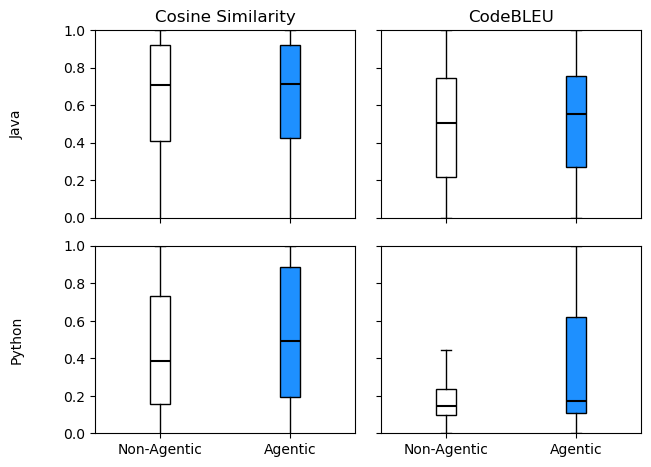

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
 
 
plot_df = pd.read_csv("plots/similarity_comparison_data.csv")

languages = plot_df["language"].unique()
colors = ["white", "dodgerblue"]

fig, axes = plt.subplots(
    len(languages),
    2,
    figsize=(7, 2.4 * len(languages)),
    squeeze=False
)

groups = plot_df.groupby(["language", "agentic"], sort=False)

# Create textual summary
summary = []

for language in languages:

    lang_df = plot_df[plot_df["language"] == language]

    for metric in ["sim", "codebleu"]:

        for agentic, label in [
            (False, "Non-Agentic"),
            (True, "Agentic")
        ]:

            values = (
                lang_df.loc[lang_df["agentic"] == agentic, metric]
                .dropna()
            )

            summary.append({
                "Language": language.capitalize(),
                "Metric": "Cosine Similarity" if metric == "sim" else "CodeBLEU",
                "Version": label,
                "N": len(values),
                "Mean": values.mean(),
                "Median": values.median(),
                "Std": values.std(),
                "Min": values.min(),
                "Q1": values.quantile(0.25),
                "Q3": values.quantile(0.75),
                "Max": values.max()
            })

summary_df = pd.DataFrame(summary)

# Format numbers for display
display(
    summary_df.style.format({
        "Mean": "{:.4f}",
        "Median": "{:.4f}",
        "Std": "{:.4f}",
        "Min": "{:.4f}",
        "Q1": "{:.4f}",
        "Q3": "{:.4f}",
        "Max": "{:.4f}"
    })
)

for row, language in enumerate(languages):

    # Retrieve groups directly
    sim_false = groups.get_group((language, False))["sim"].dropna()
    sim_true = groups.get_group((language, True))["sim"].dropna()

    codebleu_false = groups.get_group((language, False))["codebleu"].dropna()
    codebleu_true = groups.get_group((language, True))["codebleu"].dropna()


    # Cosine Similarity
    bp1 = axes[row, 0].boxplot(
        [sim_false, sim_true],
        labels=["Non-Agentic", "Agentic"],
        patch_artist=True,
        showfliers=False
    )

    for patch, color in zip(bp1["boxes"], colors):
        patch.set_facecolor(color)


    # CodeBLEU
    bp2 = axes[row, 1].boxplot(
        [codebleu_false, codebleu_true],
        labels=["Non-Agentic", "Agentic"],
        patch_artist=True,
        showfliers=False
    )

    for patch, color in zip(bp2["boxes"], colors):
        patch.set_facecolor(color)

    for median in bp1["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    for median in bp2["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    axes[row, 0].text(
        -0.30,
        0.5,
        language.capitalize(),
        transform=axes[row, 0].transAxes,
        rotation=90,
        va="center",
        ha="center"
    )

    # Consistent y-axis
    axes[row, 0].set_ylim(0, 1)
    axes[row, 1].set_ylim(0, 1)

    # Remove y-axis numbers from right plots
    axes[row, 1].set_yticklabels([])

    # Remove x-axis labels from top plots
    if row == 0:
        axes[row, 0].set_xticklabels([])
        axes[row, 1].set_xticklabels([])


# Titles
axes[0, 0].set_title("Cosine Similarity")
axes[0, 1].set_title("CodeBLEU")

plt.subplots_adjust(
    wspace=0.10,
    hspace=0.15,
    left=0.2,
    right=0.98,
    bottom=0.08,
    top=0.92
)

Path("plots").mkdir(exist_ok=True)

plt.savefig(
    "plots/similarity_comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

## Paired comparison

In [6]:
df[["sim", "codebleu"]].isna().sum()

sim         0
codebleu    0
dtype: int64

In [5]:
import re

def normalize_project(name):
    # remove the final hash part
    return re.sub(r'_[0-9a-f]{12}$', '', name)

df["project_group"] = df["project"].apply(normalize_project)

In [11]:
project_scores = (
    df
    .groupby(
        [
            "project_group",
            "base_index",
            "language",
            "agentic"
        ]
    )[["sim", "codebleu"]]
    .mean()
    .reset_index()
)

comparison = project_scores.pivot_table(
    index=["project_group", "base_index", "language"],
    columns="agentic",
    values=["sim", "codebleu"]
)

# Rename columns
comparison.columns = [
    f"{metric}_{'agentic' if agentic else 'non_agentic'}"
    for metric, agentic in comparison.columns
]

# Calculate changes
comparison["sim_change"] = (
    comparison["sim_agentic"]
    - comparison["sim_non_agentic"]
)

comparison["codebleu_change"] = (
    comparison["codebleu_agentic"]
    - comparison["codebleu_non_agentic"]
)

display(comparison.head(10))

,,,codebleu_non_agentic,codebleu_agentic,sim_non_agentic,sim_agentic,sim_change,codebleu_change
project_group,base_index,language,,,,,,
aio-libs_aiohttp,66,python,0.215197,0.227804,0.455107,0.477585,0.022477,0.012608
alibaba_druid,12,java,0.443483,0.440024,0.657736,0.655214,-0.002522,-0.003459
beast-dev_beast-mcmc,14,java,0.368574,0.366428,0.534856,0.538378,0.003522,-0.002146
bndtools_bnd,8,java,0.225645,0.223785,0.438544,0.437679,-0.000864,-0.00186
cloudera_hue,62,python,0.244635,0.467592,0.451308,0.605769,0.15446,0.222958
codespecs_daikon,0,java,0.341716,0.340631,0.538878,0.538209,-0.000669,-0.001085
cryptomator_cryptofs,6,java,0.193631,0.193927,0.459784,0.469116,0.009333,0.000296
django-helpdesk_django-helpdesk,64,python,0.134486,0.141508,0.41858,0.424244,0.005665,0.007022
django-import-export_django-import-export,58,python,0.145026,0.153159,0.323395,0.361032,0.037637,0.008133


## Evolution

In [12]:
stats_by_language = (
    comparison
    .groupby("language")[["sim_change", "codebleu_change"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
)

display(stats_by_language)

sim_change                                                  \
              count      mean    median     std       min       max   
language                                                              
java             14 -0.017488 -0.003064  0.0346 -0.099799  0.009333   
python           20  0.022684  0.010349  0.0581 -0.062921  0.184084   

         codebleu_change                                                  
                   count      mean    median     std       min       max  
language                                                                  
java                  14 -0.013864  -0.00202  0.0298 -0.094052  0.013068  
python                20  0.028606  0.007578  0.0696 -0.014393  0.234816